<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work%20/ml_ben.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" style="text-align: right;">

## شروع بخش خوشه‌بندی برای سیستم توصیه‌گر ملک

در این نوت‌بوک، بخش مربوط به مسئله‌ی اول یعنی ساخت سیستم توصیه‌گر بر اساس خوشه‌بندی املاک انجام می‌شود.

در قدم اول، کتابخانه‌های لازم را وارد می‌کنیم، Google Drive را mount می‌کنیم و فایل نهایی preprocessing را می‌خوانیم.  
برای این بخش باید از فایل `cleaned_step3_geo.parquet` استفاده کنیم، چون این فایل شامل خروجی نهایی preprocessing و ستون‌های جغرافیایی UTM است.

</div>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

# Path to final preprocessed dataset
DATA_PATH = "/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet"

# Load dataset
df = pd.read_parquet(DATA_PATH)

print("Data loaded successfully.")
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully.
Shape: (999943, 85)
Number of columns: 85


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,location_latitude,location_longitude,location_radius,created_at_shamsi,created_at_shamsi_readable,construction_year_was_missing,construction_year_imputed,transaction_type,price_value_pos,rent_value_pos,credit_value_pos,building_size_pos,land_size_pos,area_for_unit_price,monthly_rent_equivalent,credit_equivalent,sale_price_per_m2,monthly_rent_equivalent_per_m2,credit_equivalent_per_m2,target_price,target_price_type,target_price_per_m2,is_valid_area_basic,is_valid_sale_price_basic,is_valid_rent_value_basic,is_valid_credit_value_basic,is_valid_target_price_basic,is_valid_area_q01_q99_by_cat3,is_valid_target_price_per_m2_q01_q99_by_cat3,is_valid_for_price_analysis,has_geo,is_valid_geo_basic,is_valid_geo_for_analysis,utm_easting,utm_northing,utm_zone_number,utm_zone_letter
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,500.0,NaN,<NA>,NaN,3.0,NaN,NaN,False,False,False,False,NaN,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,4.0,35.811684,50.936600,500.0,1403-05,مرداد 1403,True,1395.0,temporary_rent,NaN,NaN,NaN,500.0,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,not_defined,NaN,True,True,True,True,True,True,<NA>,False,True,True,True,494272.329998,3.963064e+06,39,S
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,60.0,NaN,<NA>,3.0,1.0,NaN,NaN,False,True,True,True,1384.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,500.0,1403-02,اردیبهشت 1403,False,1384.0,sell,8.500000e+09,NaN,NaN,60.0,NaN,60.0,NaN,NaN,1.416667e+08,NaN,NaN,8.500000e+09,sale_total_price,1.416667e+08,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN,26000000.0,NaN,NaN,132.0,NaN,<NA>,3.0,3.0,NaN,NaN,False,True,True,True,1401.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,35.703865,51.373459,NaN,1403-07,مهر 1403,False,1401.0,rent,NaN,26000000.0,750000000.0,132.0,NaN,132.0,48500000.0,1.616667e+09,NaN,3.674242e+05,1.224747e+07,4.850000e+07,monthly_rent_equivalent,3.674242e+05,True,True,True,True,True,True,True,True,True,True,True,533784.424602,3.951168e+06,39,S
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN,95000000.0,NaN,NaN,90.0,NaN,<NA>,4.0,1.0,NaN,NaN,False,True,False,True,1400.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,1403-03,خرداد 1403,False,1400.0,rent,NaN,95000000.0,950000000.0,90.0,NaN,90.0,123500000.0,4.116667e+09,NaN,1.372222e+06,4.574074e+07,1.235000e+08,monthly_rent_equivalent,1.372222e+06,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱

<div dir="rtl" style="text-align: right;">

## اعمال فیلتر پایه برای خوشه‌بندی

برای اینکه خوشه‌بندی روی داده‌های معتبر انجام شود، ابتدا فقط آگهی‌هایی را نگه می‌داریم که از نظر قیمت و موقعیت جغرافیایی معتبر هستند.

همچنین چون داده‌ها در چند UTM zone مختلف قرار دارند، فقط داده‌های مربوط به UTM zone 39S را انتخاب می‌کنیم.  
اگر مختصات UTM مربوط به zoneهای مختلف را مستقیماً با هم مقایسه کنیم، فاصله‌ی جغرافیایی بین نقاط معنای درستی نخواهد داشت.

در این مرحله ستون `log_target_price` هم ساخته می‌شود، چون قیمت ملک راست‌چوله است و استفاده از لگاریتم قیمت باعث می‌شود اثر قیمت‌های بسیار بزرگ کمتر شود.

</div>

In [3]:
# Create base filter for clustering
base_mask = (
    (df["is_valid_for_price_analysis"].fillna(False) == True) &
    (df["is_valid_geo_for_analysis"].fillna(False) == True) &
    (df["target_price"] > 0) &
    (df["utm_zone_number"] == 39) &
    (df["utm_zone_letter"] == "S")
)

# Apply filter
df_clustering = df.loc[base_mask].copy()

# Create log-transformed target price
df_clustering["log_target_price"] = np.log1p(df_clustering["target_price"])

print("Rows before filtering:", len(df))
print("Rows after base clustering filter:", len(df_clustering))
print("Columns after adding log_target_price:", df_clustering.shape[1])

# Quick check of important columns
df_clustering[
    [
        "city_slug",
        "cat3_slug",
        "target_price",
        "log_target_price",
        "utm_easting",
        "utm_northing",
        "utm_zone_number",
        "utm_zone_letter"
    ]
].head()

Rows before filtering: 999943
Rows after base clustering filter: 404253
Columns after adding log_target_price: 86


,city_slug,cat3_slug,target_price,log_target_price,utm_easting,utm_northing,utm_zone_number,utm_zone_letter
2,tehran,apartment-rent,4.850000e+07,17.697074,533784.424602,3.951168e+06,39,S
7,tehran,apartment-sell,8.700000e+09,22.886589,545711.558185,3.954101e+06,39,S
8,mahdasht-city,apartment-sell,6.500000e+08,20.292483,481437.130969,3.952066e+06,39,S
10,pardis-city,apartment-sell,2.600000e+09,21.678777,568467.028494,3.959664e+06,39,S
11,tehran,apartment-rent,3.600000e+07,17.399030,534418.187237,3.954507e+06,39,S


<div dir="rtl" style="text-align: right;">

## انتخاب ویژگی‌های خوشه‌بندی و بررسی مقادیر گم‌شده

در این بخش ویژگی‌هایی را انتخاب می‌کنیم که برای ساخت خوشه‌های معنادار در سیستم توصیه‌گر ملک مناسب هستند.

ویژگی‌های انتخاب‌شده شامل موقعیت جغرافیایی، قیمت و مشخصات پایه‌ی ملک هستند:

- `utm_easting`: موقعیت شرقی ملک در سیستم UTM
- `utm_northing`: موقعیت شمالی ملک در سیستم UTM
- `log_target_price`: لگاریتم قیمت هدف
- `building_size_pos`: متراژ مثبت ساختمان
- `rooms_count`: تعداد اتاق‌ها

این ویژگی‌ها زیاد نیستند، بنابراین تا حدی از مشکل نفرین ابعاد جلوگیری می‌شود.  
در عین حال، ترکیب آن‌ها می‌تواند نیازهای مهم کاربر مثل موقعیت، بودجه، متراژ و تعداد اتاق را پوشش دهد.

قبل از اجرای KMeans باید مطمئن شویم که این ستون‌ها مقدار گم‌شده ندارند، چون الگوریتم KMeans نمی‌تواند مستقیماً با NaN کار کند.

</div>

In [4]:
# Features selected for KMeans clustering
cluster_features = [
    "utm_easting",
    "utm_northing",
    "log_target_price",
    "building_size_pos",
    "rooms_count"
]

# Check missing values in selected features
missing_summary = (
    df_clustering[cluster_features]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["feature", "missing_count"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(df_clustering) * 100
).round(4)

print("Selected features:")
print(cluster_features)

print("\nMissing values summary:")
display(missing_summary)

# Basic descriptive statistics
df_clustering[cluster_features].describe().T

Selected features:
['utm_easting', 'utm_northing', 'log_target_price', 'building_size_pos', 'rooms_count']

Missing values summary:


,feature,missing_count,missing_percentage
0,utm_easting,0,0.0
1,utm_northing,0,0.0
2,log_target_price,0,0.0
3,building_size_pos,0,0.0
4,rooms_count,0,0.0


,count,mean,std,min,25%,50%,75%,max
utm_easting,404253.0,4.997282e+05,86466.399296,2.204880e+05,4.901632e+05,5.272183e+05,5.430324e+05,7.825825e+05
utm_northing,404253.0,3.935309e+06,128996.745443,3.540532e+06,3.936165e+06,3.953605e+06,3.965068e+06,4.396585e+06
log_target_price,404253.0,1.992221e+01,2.743300,1.030899e+01,1.699356e+01,2.105974e+01,2.210956e+01,2.693787e+01
building_size_pos,404253.0,1.949029e+02,705.740648,1.000000e+01,7.000000e+01,9.500000e+01,1.400000e+02,2.000000e+04
rooms_count,404253.0,1.859655e+00,0.866313,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00


<div dir="rtl" style="text-align: right;">

## مقیاس‌بندی ویژگی‌ها برای اجرای KMeans

الگوریتم KMeans بر اساس فاصله‌ی بین نقاط کار می‌کند.  
بنابراین اگر ویژگی‌ها مقیاس‌های خیلی متفاوتی داشته باشند، ویژگی‌هایی با عددهای بزرگ‌تر اثر بیشتری روی خوشه‌بندی می‌گذارند.

در این داده، مختصات UTM در مقیاس صد هزار و چند میلیون است، اما تعداد اتاق‌ها عددی کوچک بین ۰ تا ۵ دارد.  
برای جلوگیری از غالب شدن مختصات روی بقیه‌ی ویژگی‌ها، همه‌ی ویژگی‌ها را با `StandardScaler` استاندارد می‌کنیم.

بعد از استانداردسازی، میانگین هر ویژگی تقریباً ۰ و انحراف معیار آن تقریباً ۱ می‌شود.

</div>

In [5]:
# Create feature matrix
X = df_clustering[cluster_features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled array to DataFrame for easier checking
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=df_clustering.index
)

print("Original feature matrix shape:", X.shape)
print("Scaled feature matrix shape:", X_scaled_df.shape)

# Check mean and standard deviation after scaling
scaling_check = pd.DataFrame({
    "scaled_mean": X_scaled_df.mean().round(6),
    "scaled_std": X_scaled_df.std().round(6)
})

display(scaling_check)

X_scaled_df.head()

Original feature matrix shape: (404253, 5)
Scaled feature matrix shape: (404253, 5)


,scaled_mean,scaled_std
utm_easting,-0.0,1.000001
utm_northing,0.0,1.000001
log_target_price,0.0,1.000001
building_size_pos,0.0,1.000001
rooms_count,0.0,1.000001


,utm_easting,utm_northing,log_target_price,building_size_pos,rooms_count
2,0.393867,0.122938,-0.811118,-0.089131,1.316322
7,0.531807,0.145679,1.080590,-0.134473,0.162003
8,-0.211540,0.129898,0.134973,-0.165646,0.162003
10,0.794978,0.188803,0.640312,-0.152893,0.162003
11,0.401196,0.148826,-0.919763,-0.147226,0.162003


<div dir="rtl" style="text-align: right;">

## اجرای KMeans برای kهای ۱ تا ۲۰ و محاسبه WCSS

در این مرحله، الگوریتم KMeans را برای تعداد خوشه‌های مختلف از ۱ تا ۲۰ اجرا می‌کنیم.

برای هر مقدار `k`، مقدار `inertia_` مدل را ذخیره می‌کنیم.  
در Scikit-learn مقدار `inertia_` همان مجموع مجذورات فاصله‌ی نقاط تا مرکز خوشه‌ی خودشان است که به آن WCSS یا Within-Cluster Sum of Squares گفته می‌شود.

هرچه تعداد خوشه‌ها بیشتر شود، مقدار WCSS کمتر می‌شود؛ اما هدف این نیست که WCSS را تا جای ممکن کم کنیم.  
هدف این است که نقطه‌ای را پیدا کنیم که بعد از آن، اضافه کردن خوشه‌های بیشتر کاهش چشمگیری در WCSS ایجاد نکند. این نقطه معمولاً به عنوان elbow یا آرنج نمودار شناخته می‌شود.

</div>

In [6]:
import time

# Range of k values
k_values = range(1, 21)

# Store WCSS values
wcss_values = []

start_time = time.time()

for k in k_values:
    print(f"Running KMeans for k={k} ...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss_values.append(kmeans.inertia_)

end_time = time.time()

# Create WCSS results table
wcss_df = pd.DataFrame({
    "k": list(k_values),
    "wcss": wcss_values
})

print("KMeans models finished.")
print(f"Total runtime: {(end_time - start_time) / 60:.2f} minutes")

display(wcss_df)

Running KMeans for k=1 ...
Running KMeans for k=2 ...
Running KMeans for k=3 ...
Running KMeans for k=4 ...
Running KMeans for k=5 ...
Running KMeans for k=6 ...
Running KMeans for k=7 ...
Running KMeans for k=8 ...
Running KMeans for k=9 ...
Running KMeans for k=10 ...
Running KMeans for k=11 ...
Running KMeans for k=12 ...
Running KMeans for k=13 ...
Running KMeans for k=14 ...
Running KMeans for k=15 ...
Running KMeans for k=16 ...
Running KMeans for k=17 ...
Running KMeans for k=18 ...
Running KMeans for k=19 ...
Running KMeans for k=20 ...
KMeans models finished.
Total runtime: 2.22 minutes


,k,wcss
0,1,2.021265e+06
1,2,1.654620e+06
2,3,1.378393e+06
3,4,1.137940e+06
4,5,9.490049e+05
5,6,8.281275e+05
6,7,7.041064e+05
7,8,6.286319e+05
8,9,5.758953e+05
9,10,5.258700e+05


<div dir="rtl" style="text-align: right;">

## رسم نمودار Elbow و محاسبه درصد کاهش WCSS

بعد از اجرای KMeans برای kهای مختلف، مقدار WCSS را برای هر k بررسی می‌کنیم.

در روش Elbow، به دنبال نقطه‌ای هستیم که قبل از آن کاهش WCSS زیاد است، اما بعد از آن اضافه کردن خوشه‌های بیشتر کاهش چشمگیری ایجاد نمی‌کند.

برای تحلیل دقیق‌تر، علاوه بر نمودار WCSS، درصد کاهش WCSS نسبت به k قبلی را هم محاسبه می‌کنیم.  
این کار کمک می‌کند انتخاب k فقط بر اساس نگاه چشمی به نمودار نباشد و استدلال عددی هم داشته باشد.

</div>

,k,wcss,wcss_diff,wcss_decrease,wcss_decrease_percent
0,1,2.021265e+06,NaN,NaN,NaN
1,2,1.654620e+06,-366644.605164,366644.605164,18.14
2,3,1.378393e+06,-276227.827354,276227.827354,16.69
3,4,1.137940e+06,-240452.683495,240452.683495,17.44
4,5,9.490049e+05,-188934.951464,188934.951464,16.60
5,6,8.281275e+05,-120877.438366,120877.438366,12.74
6,7,7.041064e+05,-124021.098116,124021.098116,14.98
7,8,6.286319e+05,-75474.530342,75474.530342,10.72
8,9,5.758953e+05,-52736.575956,52736.575956,8.39
9,10,5.258700e+05,-50025.254476,50025.254476,8.69


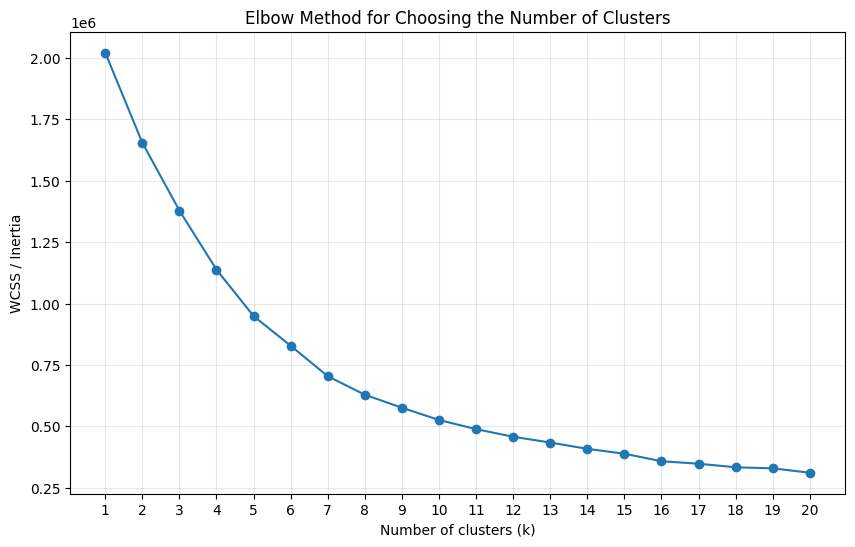

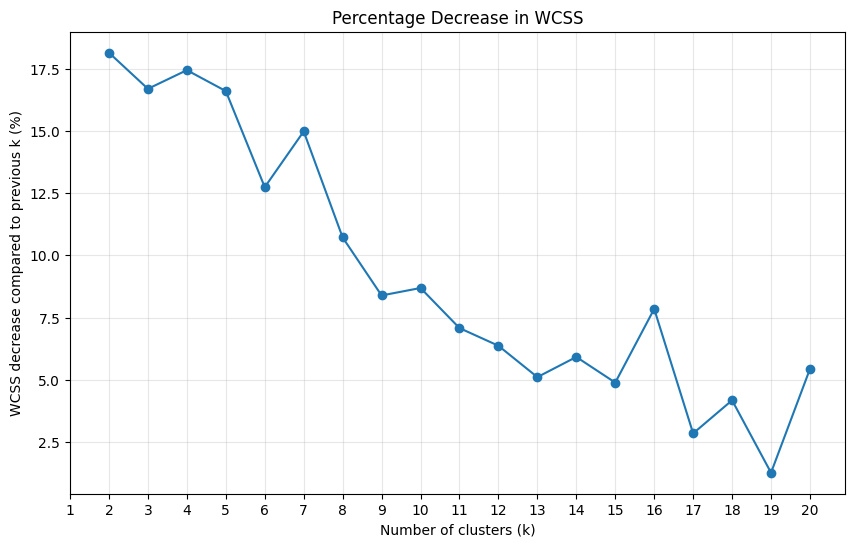

In [7]:
# Calculate WCSS decrease compared to previous k
wcss_df["wcss_diff"] = wcss_df["wcss"].diff()
wcss_df["wcss_decrease"] = -wcss_df["wcss_diff"]

# Percentage decrease compared to previous WCSS
wcss_df["wcss_decrease_percent"] = (
    wcss_df["wcss_decrease"] / wcss_df["wcss"].shift(1) * 100
).round(2)

# For k=1, decrease is not defined
wcss_df.loc[wcss_df["k"] == 1, ["wcss_diff", "wcss_decrease", "wcss_decrease_percent"]] = np.nan

display(wcss_df)

# Plot elbow chart
plt.figure(figsize=(10, 6))

plt.plot(
    wcss_df["k"],
    wcss_df["wcss"],
    marker="o"
)

plt.xticks(wcss_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for Choosing the Number of Clusters")
plt.grid(True, alpha=0.3)

plt.show()

# Plot percentage decrease chart
plt.figure(figsize=(10, 6))

plt.plot(
    wcss_df["k"],
    wcss_df["wcss_decrease_percent"],
    marker="o"
)

plt.xticks(wcss_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS decrease compared to previous k (%)")
plt.title("Percentage Decrease in WCSS")
plt.grid(True, alpha=0.3)

plt.show()

<div dir="rtl" style="text-align: right;">

## انتخاب عدد مناسب k با روش کمکی فاصله از خط

نمودار Elbow همیشه یک نقطه‌ی شکست کاملاً واضح نشان نمی‌دهد.  
در این داده هم مقدار WCSS با افزایش k به‌صورت پیوسته کم می‌شود، اما شکست نمودار خیلی تیز نیست.

برای اینکه انتخاب k فقط چشمی نباشد، از یک روش کمکی استفاده می‌کنیم:  
ابتدا مقادیر k و WCSS را نرمال‌سازی می‌کنیم، سپس خطی بین نقطه‌ی اول و آخر نمودار رسم می‌کنیم.  
نقطه‌ای که بیشترین فاصله را از این خط داشته باشد، به‌عنوان یکی از گزینه‌های مناسب برای elbow در نظر گرفته می‌شود.

این روش جای تحلیل انسانی را نمی‌گیرد، اما به انتخاب عدد k یک پشتوانه‌ی عددی می‌دهد.

</div>

Suggested k based on maximum distance from line: 7


,k,wcss,wcss_decrease_percent,distance_from_line
0,1,2.021265e+06,NaN,0.000000
1,2,1.654620e+06,18.14,0.114383
2,3,1.378393e+06,16.69,0.191381
3,4,1.137940e+06,17.44,0.253586
4,5,9.490049e+05,16.60,0.294491
5,6,8.281275e+05,12.74,0.307254
6,7,7.041064e+05,14.98,0.321318
7,8,6.286319e+05,10.72,0.315309
8,9,5.758953e+05,8.39,0.299898
9,10,5.258700e+05,8.69,0.283366


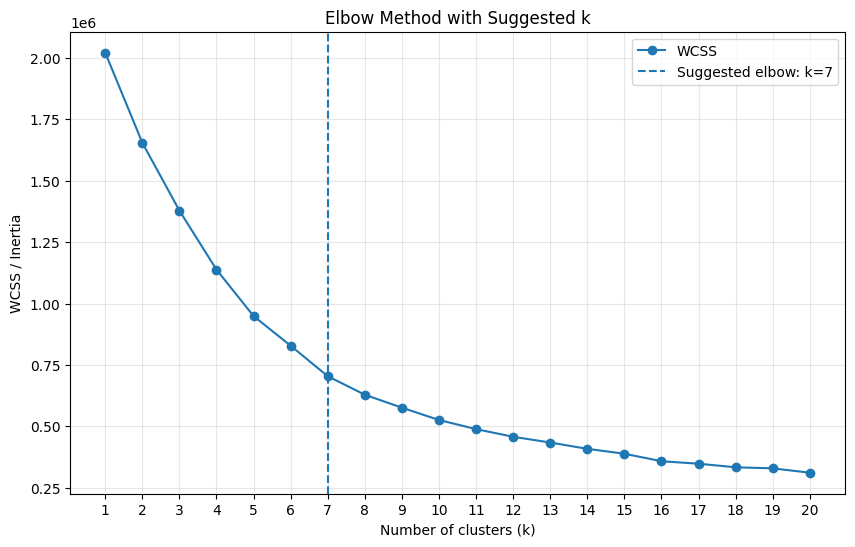

In [8]:
# Normalize k and WCSS values
k_array = wcss_df["k"].values
wcss_array = wcss_df["wcss"].values

k_norm = (k_array - k_array.min()) / (k_array.max() - k_array.min())
wcss_norm = (wcss_array - wcss_array.min()) / (wcss_array.max() - wcss_array.min())

# Points in normalized space
points = np.column_stack((k_norm, wcss_norm))

# First and last points
first_point = points[0]
last_point = points[-1]

# Vector from first to last point
line_vector = last_point - first_point
line_vector_norm = np.linalg.norm(line_vector)

# Calculate distance of each point from the line
distances = []

for point in points:
    distance = abs(
        line_vector[0] * (first_point[1] - point[1]) -
        line_vector[1] * (first_point[0] - point[0])
    ) / line_vector_norm

    distances.append(distance)

wcss_df["distance_from_line"] = distances

# Suggested elbow based on maximum distance
suggested_k = int(wcss_df.loc[wcss_df["distance_from_line"].idxmax(), "k"])

print("Suggested k based on maximum distance from line:", suggested_k)

display(wcss_df[["k", "wcss", "wcss_decrease_percent", "distance_from_line"]])

# Plot WCSS with suggested elbow
plt.figure(figsize=(10, 6))

plt.plot(
    wcss_df["k"],
    wcss_df["wcss"],
    marker="o",
    label="WCSS"
)

plt.axvline(
    x=suggested_k,
    linestyle="--",
    label=f"Suggested elbow: k={suggested_k}"
)

plt.xticks(wcss_df["k"])
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method with Suggested k")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

<div dir="rtl" style="text-align: right;">

## تحلیل نهایی انتخاب مقدار k

برای انتخاب تعداد مناسب خوشه‌ها، الگوریتم KMeans برای مقادیر مختلف `k` از ۱ تا ۲۰ اجرا شد و برای هر مقدار، WCSS یا همان مجموع مجذورات درون‌خوشه‌ای محاسبه شد.

همان‌طور که انتظار می‌رفت، با افزایش تعداد خوشه‌ها مقدار WCSS کاهش پیدا کرد. دلیل این موضوع این است که وقتی تعداد خوشه‌ها بیشتر می‌شود، هر نقطه می‌تواند به مرکز خوشه‌ی نزدیک‌تری اختصاص داده شود. با این حال، هدف انتخاب بیشترین تعداد خوشه نیست؛ بلکه باید مقداری انتخاب شود که بعد از آن، اضافه کردن خوشه‌های جدید بهبود چشمگیری ایجاد نکند.

بر اساس نمودار Elbow، شکست نمودار کاملاً تیز و واضح نیست، اما کاهش WCSS بعد از حدود `k=7` آرام‌تر می‌شود. برای اینکه انتخاب k فقط بر اساس مشاهده‌ی چشمی نباشد، از روش فاصله‌ی نقاط نمودار از خط اتصال نقطه‌ی اول و آخر نیز استفاده شد. در این روش، مقدار `k=7` بیشترین فاصله را از خط داشت؛ بنابراین به عنوان گزینه‌ی پیشنهادی برای تعداد خوشه‌ها انتخاب شد.

از نظر عددی نیز مقدار کاهش WCSS تا قبل از `k=7` نسبتاً زیاد است. برای مثال کاهش WCSS از `k=6` به `k=7` حدود `14.98%` است، اما بعد از آن مقدار کاهش‌ها معمولاً کمتر می‌شود؛ مثلاً از `k=8` به `k=9` حدود `8.39%` و از `k=10` به `k=11` حدود `7.08%` است. این نشان می‌دهد که بعد از محدوده‌ی ۷ خوشه، اضافه کردن خوشه‌های بیشتر همچنان WCSS را کم می‌کند، اما بازدهی آن کمتر از مراحل اولیه است.

بنابراین، برای این داده و با توجه به روش Elbow و معیار فاصله از خط، مقدار پیشنهادی ما برای KMeans برابر با `k=7` است.

البته مقدار `k=10` که در بخش قبل استفاده شده بود نیز کاملاً غیرمنطقی نیست. چون از `k=9` به `k=10` هنوز حدود `8.69%` کاهش WCSS دیده می‌شود و در کاربرد سیستم توصیه‌گر، داشتن خوشه‌های بیشتر می‌تواند باعث تفکیک دقیق‌تر سلیقه و نیاز کاربران شود. با این حال، اگر هدف انتخاب یک مقدار متعادل‌تر و ساده‌تر باشد، `k=7` گزینه‌ی مناسب‌تری است؛ زیرا بین کاهش WCSS، سادگی مدل و قابل تفسیر بودن خوشه‌ها تعادل بهتری ایجاد می‌کند.

در نتیجه، انتخاب نهایی این بخش `k=7` است، اما استفاده از `k=10` برای تحلیل دقیق‌تر یا ساخت سگمنت‌های جزئی‌تر در سیستم توصیه‌گر نیز قابل دفاع است.

</div>

<div dir="rtl" style="text-align: right;">

## آماده‌سازی داده برای DBSCAN

در این بخش از الگوریتم DBSCAN برای خوشه‌بندی املاک استفاده می‌کنیم.

برخلاف KMeans که تعداد خوشه‌ها را از ابتدا مشخص می‌کند، DBSCAN بر اساس تراکم نقاط کار می‌کند.  
بنابراین می‌تواند نقاط پرت یا noise را نیز شناسایی کند.

طبق صورت سؤال، برای DBSCAN از مختصات UTM و قیمت استفاده می‌کنیم.  
برای قیمت، به جای مقدار خام `target_price` از `log_target_price` استفاده می‌شود، چون قیمت ملک توزیع راست‌چوله دارد و مقادیر بسیار بزرگ می‌توانند فاصله‌ها را شدیداً تحت تأثیر قرار دهند.

ویژگی‌های انتخاب‌شده برای DBSCAN:

- `utm_easting`
- `utm_northing`
- `log_target_price`

از آنجا که DBSCAN برای داده‌های بزرگ می‌تواند از نظر زمانی و حافظه سنگین باشد، ابتدا یک نمونه‌ی تصادفی از داده‌ها برای تست هایپرپارامترها انتخاب می‌کنیم.

</div>

In [13]:
from sklearn.cluster import DBSCAN

# Features for DBSCAN
dbscan_features = [
    "utm_easting",
    "utm_northing",
    "log_target_price"
]

# Create DBSCAN dataframe
df_dbscan = df_clustering[dbscan_features].copy()

print("DBSCAN full data shape:", df_dbscan.shape)

# Scale DBSCAN features
dbscan_scaler = StandardScaler()
X_dbscan_scaled = dbscan_scaler.fit_transform(df_dbscan)

X_dbscan_scaled_df = pd.DataFrame(
    X_dbscan_scaled,
    columns=dbscan_features,
    index=df_dbscan.index
)

# Check scaling
dbscan_scaling_check = pd.DataFrame({
    "scaled_mean": X_dbscan_scaled_df.mean().round(6),
    "scaled_std": X_dbscan_scaled_df.std().round(6)
})

display(dbscan_scaling_check)

# Create a sample for DBSCAN hyperparameter tuning
DBSCAN_SAMPLE_SIZE = 15000

df_dbscan_sample = X_dbscan_scaled_df.sample(
    n=DBSCAN_SAMPLE_SIZE,
    random_state=42
)

print("DBSCAN sample shape:", df_dbscan_sample.shape)

df_dbscan_sample.head()

DBSCAN full data shape: (404253, 3)


,scaled_mean,scaled_std
utm_easting,-0.0,1.000001
utm_northing,0.0,1.000001
log_target_price,0.0,1.000001


DBSCAN sample shape: (15000, 3)


,utm_easting,utm_northing,log_target_price
960545,-1.434297,1.501250,-0.838421
927841,-0.105965,0.152116,0.738101
246503,-0.139295,-0.822049,0.823706
77807,0.307860,0.161305,1.001337
479946,-0.032167,0.243743,-0.771286


<div dir="rtl" style="text-align: right;">

## تست هایپرپارامترهای DBSCAN

در این مرحله چند مقدار مختلف برای `eps` و `min_samples` تست می‌کنیم.

هدف این است که ببینیم با چه تنظیماتی می‌توانیم به تعداد کمی خوشه‌ی معنادار برسیم.  
در DBSCAN تعداد خوشه‌ها از قبل داده نمی‌شود، بلکه از روی تراکم نقاط به‌دست می‌آید.

برای هر ترکیب از هایپرپارامترها، موارد زیر را بررسی می‌کنیم:

- تعداد کل خوشه‌ها، بدون در نظر گرفتن noise
- تعداد نقاط noise با label برابر `-1`
- درصد noise
- اندازه‌ی چند خوشه‌ی بزرگ‌تر

</div>

In [15]:
import time
from collections import Counter

# Candidate hyperparameters
eps_values = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
min_samples_values = [50, 100]

dbscan_results = []

start_time = time.time()

for eps in eps_values:
    for min_samples in min_samples_values:
        print(f"Running DBSCAN with eps={eps}, min_samples={min_samples} ...")

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=-1
        )

        labels = model.fit_predict(df_dbscan_sample)

        label_counts = Counter(labels)

        # Number of clusters excluding noise label -1
        cluster_labels = [label for label in label_counts.keys() if label != -1]
        n_clusters = len(cluster_labels)

        noise_count = label_counts.get(-1, 0)
        noise_percentage = noise_count / len(labels) * 100

        # Largest non-noise clusters
        non_noise_cluster_sizes = sorted(
            [count for label, count in label_counts.items() if label != -1],
            reverse=True
        )

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_count": noise_count,
            "noise_percentage": round(noise_percentage, 2),
            "largest_cluster_sizes": non_noise_cluster_sizes[:5]
        })

end_time = time.time()

dbscan_results_df = pd.DataFrame(dbscan_results)

print("DBSCAN tuning finished.")
print(f"Total runtime: {(end_time - start_time) / 60:.2f} minutes")

display(dbscan_results_df)

Running DBSCAN with eps=0.05, min_samples=50 ...
Running DBSCAN with eps=0.05, min_samples=100 ...
Running DBSCAN with eps=0.08, min_samples=50 ...
Running DBSCAN with eps=0.08, min_samples=100 ...
Running DBSCAN with eps=0.1, min_samples=50 ...
Running DBSCAN with eps=0.1, min_samples=100 ...
Running DBSCAN with eps=0.12, min_samples=50 ...
Running DBSCAN with eps=0.12, min_samples=100 ...
Running DBSCAN with eps=0.15, min_samples=50 ...
Running DBSCAN with eps=0.15, min_samples=100 ...
Running DBSCAN with eps=0.2, min_samples=50 ...
Running DBSCAN with eps=0.2, min_samples=100 ...
DBSCAN tuning finished.
Total runtime: 0.05 minutes


,eps,min_samples,n_clusters,noise_count,noise_percentage,largest_cluster_sizes
0,0.05,50,11,11205,74.70,"[1230, 804, 623, 511, 182]"
1,0.05,100,2,14299,95.33,"[376, 325]"
2,0.08,50,16,7527,50.18,"[2242, 2169, 1215, 683, 208]"
3,0.08,100,5,9808,65.39,"[2054, 2004, 700, 239, 195]"
4,0.10,50,11,6332,42.21,"[4134, 2355, 858, 277, 219]"
5,0.10,100,5,8377,55.85,"[2303, 2172, 1268, 668, 212]"
6,0.12,50,13,5350,35.67,"[4320, 3401, 407, 343, 248]"
7,0.12,100,7,7302,48.68,"[2437, 2288, 1576, 830, 218]"
8,0.15,50,12,4327,28.85,"[4772, 3641, 511, 442, 296]"
9,0.15,100,7,5907,39.38,"[4372, 3411, 352, 337, 251]"


<div dir="rtl" style="text-align: right;">

## تست سبک‌تر DBSCAN برای جلوگیری از مصرف زیاد RAM

در اجرای قبلی، تست DBSCAN روی نمونه‌ی ۵۰ هزار ردیفی و تعداد زیادی ترکیب از `eps` و `min_samples` باعث مصرف زیاد حافظه شد.

DBSCAN برای هر نقطه همسایه‌های نزدیک را پیدا می‌کند و وقتی `eps` بزرگ باشد، تعداد همسایه‌ها زیاد می‌شود. بنابراین مصرف RAM می‌تواند خیلی بالا برود.

برای جلوگیری از کرش، در این مرحله از نمونه‌ی کوچک‌تر و تعداد ترکیب‌های کمتر استفاده می‌کنیم. همچنین `n_jobs=1` قرار داده می‌شود تا مصرف حافظه کنترل‌شده‌تر باشد.

</div>

In [16]:
# Safer and lighter DBSCAN tuning
eps_values_refined = [0.18, 0.22, 0.26, 0.30]
min_samples_values_refined = [100, 200, 300]

meaningful_cluster_min_size = int(0.05 * len(df_dbscan_sample))  # 5% of sample

safe_results = []

start_time = time.time()

for eps in eps_values_refined:
    for min_samples in min_samples_values_refined:
        print(f"Running DBSCAN with eps={eps}, min_samples={min_samples} ...")

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            n_jobs=1
        )

        labels = model.fit_predict(df_dbscan_sample)
        label_counts = Counter(labels)

        cluster_sizes = {
            label: count
            for label, count in label_counts.items()
            if label != -1
        }

        n_clusters_total = len(cluster_sizes)

        noise_count = label_counts.get(-1, 0)
        noise_percentage = noise_count / len(labels) * 100

        meaningful_clusters = {
            label: count
            for label, count in cluster_sizes.items()
            if count >= meaningful_cluster_min_size
        }

        n_meaningful_clusters = len(meaningful_clusters)

        largest_cluster_sizes = sorted(
            cluster_sizes.values(),
            reverse=True
        )[:10]

        safe_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters_total": n_clusters_total,
            "n_meaningful_clusters_5pct": n_meaningful_clusters,
            "noise_count": noise_count,
            "noise_percentage": round(noise_percentage, 2),
            "largest_cluster_sizes": largest_cluster_sizes
        })

end_time = time.time()

safe_dbscan_results_df = pd.DataFrame(safe_results)

print("Safe DBSCAN tuning finished.")
print(f"Total runtime: {(end_time - start_time) / 60:.2f} minutes")
print("Minimum size for meaningful cluster:", meaningful_cluster_min_size)

display(safe_dbscan_results_df)

Running DBSCAN with eps=0.18, min_samples=100 ...
Running DBSCAN with eps=0.18, min_samples=200 ...
Running DBSCAN with eps=0.18, min_samples=300 ...
Running DBSCAN with eps=0.22, min_samples=100 ...
Running DBSCAN with eps=0.22, min_samples=200 ...
Running DBSCAN with eps=0.22, min_samples=300 ...
Running DBSCAN with eps=0.26, min_samples=100 ...
Running DBSCAN with eps=0.26, min_samples=200 ...
Running DBSCAN with eps=0.26, min_samples=300 ...
Running DBSCAN with eps=0.3, min_samples=100 ...
Running DBSCAN with eps=0.3, min_samples=200 ...
Running DBSCAN with eps=0.3, min_samples=300 ...
Safe DBSCAN tuning finished.
Total runtime: 0.11 minutes
Minimum size for meaningful cluster: 750


,eps,min_samples,n_clusters_total,n_meaningful_clusters_5pct,noise_count,noise_percentage,largest_cluster_sizes
0,0.18,100,7,2,4914,32.76,"[4947, 3528, 497, 428, 293, 255, 138]"
1,0.18,200,4,2,6699,44.66,"[4412, 3427, 233, 229]"
2,0.18,300,2,2,7508,50.05,"[4266, 3226]"
3,0.22,100,7,2,3886,25.91,"[5187, 3915, 562, 524, 430, 337, 159]"
4,0.22,200,5,2,5302,35.35,"[5030, 3633, 434, 401, 200]"
5,0.22,300,2,2,6604,44.03,"[4831, 3565]"
6,0.26,100,7,2,3416,22.77,"[5286, 3960, 635, 567, 550, 381, 205]"
7,0.26,200,6,2,4216,28.11,"[5194, 3894, 543, 499, 344, 310]"
8,0.26,300,3,2,5670,37.80,"[5086, 3807, 437]"
9,0.30,100,8,1,2929,19.53,"[9333, 667, 631, 589, 394, 234, 119, 104]"


<div dir="rtl" style="text-align: right;">

## اجرای نهایی DBSCAN با هایپرپارامتر منتخب

بر اساس تست‌های انجام‌شده، ترکیب `eps=0.26` و `min_samples=300` دقیقاً ۳ خوشه تولید کرد.

در این مرحله DBSCAN را با همین تنظیمات روی نمونه‌ی ۱۵ هزار ردیفی اجرا می‌کنیم و خروجی را بررسی می‌کنیم.  
برای تحلیل بهتر، label هر نقطه را به داده‌ی اصلی نمونه اضافه می‌کنیم تا بتوانیم ویژگی‌های هر خوشه را از نظر قیمت، موقعیت جغرافیایی، شهر و نوع ملک بررسی کنیم.

در DBSCAN، label برابر با `-1` نشان‌دهنده‌ی نقاط noise است؛ یعنی نقاطی که به هیچ خوشه‌ی پرتراکمی تعلق نگرفته‌اند.

</div>

In [17]:
# Final DBSCAN model based on tuning results
final_eps = 0.26
final_min_samples = 300

final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    n_jobs=1
)

final_dbscan_labels = final_dbscan.fit_predict(df_dbscan_sample)

# Create a copy of original rows corresponding to the DBSCAN sample
df_dbscan_final = df_clustering.loc[df_dbscan_sample.index].copy()
df_dbscan_final["dbscan_cluster"] = final_dbscan_labels

# Cluster counts
cluster_counts = (
    df_dbscan_final["dbscan_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["dbscan_cluster", "count"]
cluster_counts["percentage"] = (
    cluster_counts["count"] / len(df_dbscan_final) * 100
).round(2)

print("Final DBSCAN parameters:")
print("eps:", final_eps)
print("min_samples:", final_min_samples)

print("\nCluster counts:")
display(cluster_counts)

# Summary statistics for non-noise clusters
cluster_summary = (
    df_dbscan_final[df_dbscan_final["dbscan_cluster"] != -1]
    .groupby("dbscan_cluster")
    .agg(
        ads_count=("dbscan_cluster", "size"),
        median_target_price=("target_price", "median"),
        mean_target_price=("target_price", "mean"),
        median_log_target_price=("log_target_price", "median"),
        median_utm_easting=("utm_easting", "median"),
        median_utm_northing=("utm_northing", "median"),
        median_building_size=("building_size_pos", "median")
    )
    .reset_index()
)

# Convert price to billion toman for easier reading
cluster_summary["median_target_price_billion"] = (
    cluster_summary["median_target_price"] / 1e9
).round(2)

cluster_summary["mean_target_price_billion"] = (
    cluster_summary["mean_target_price"] / 1e9
).round(2)

display(cluster_summary)

# Top cities in each cluster
for cluster_id in sorted(df_dbscan_final["dbscan_cluster"].unique()):
    if cluster_id == -1:
        continue

    print(f"\nTop cities for cluster {cluster_id}:")
    display(
        df_dbscan_final[df_dbscan_final["dbscan_cluster"] == cluster_id]["city_slug"]
        .value_counts()
        .head(5)
        .reset_index()
        .rename(columns={"index": "city_slug", "city_slug": "count"})
    )

# Top property types in each cluster
for cluster_id in sorted(df_dbscan_final["dbscan_cluster"].unique()):
    if cluster_id == -1:
        continue

    print(f"\nTop cat3_slug values for cluster {cluster_id}:")
    display(
        df_dbscan_final[df_dbscan_final["dbscan_cluster"] == cluster_id]["cat3_slug"]
        .value_counts()
        .head(5)
        .reset_index()
        .rename(columns={"index": "cat3_slug", "cat3_slug": "count"})
    )

Final DBSCAN parameters:
eps: 0.26
min_samples: 300

Cluster counts:


,dbscan_cluster,count,percentage
0,-1,5670,37.80
1,0,5086,33.91
2,1,3807,25.38
3,2,437,2.91


,dbscan_cluster,ads_count,median_target_price,mean_target_price,median_log_target_price,median_utm_easting,median_utm_northing,median_building_size,median_target_price_billion,mean_target_price_billion
0,0,5086,3.700000e+09,6.458995e+09,22.031599,527453.369334,3.952736e+06,85.0,3.70,6.46
1,1,3807,2.250000e+07,3.783193e+07,16.929026,532091.358184,3.953968e+06,86.0,0.02,0.04
2,2,437,1.750000e+09,1.861279e+09,21.282882,600315.443319,4.041689e+06,140.0,1.75,1.86



Top cities for cluster 0:


,count,count
0,tehran,2449
1,karaj,674
2,andisheh-new-town,421
3,pardis-city,225
4,eslamshahr,144


...

,count,count
0,apartment-sell,4138
1,house-villa-sell,362
2,plot-old,332
3,shop-sell,150
4,office-sell,60



Top cat3_slug values for cluster 1:


,count,count
0,apartment-rent,2847
1,shop-rent,340
2,office-rent,268
3,house-villa-rent,217
4,industry-agriculture-business-rent,83



Top cat3_slug values for cluster 2:


,count,count
0,house-villa-sell,374
1,plot-old,49
2,apartment-sell,11
3,office-sell,1
4,shop-sell,1


<div dir="rtl" style="text-align: right;">

## رسم Scatter Plot خروجی DBSCAN

در این بخش خروجی نهایی DBSCAN را به صورت تصویری بررسی می‌کنیم.

چون مدل DBSCAN با سه ویژگی `utm_easting`، `utm_northing` و `log_target_price` آموزش داده شده است، برای نمایش دوبعدی از دو نوع نمودار استفاده می‌کنیم:

1. نمودار مکانی بر اساس مختصات UTM  
2. نمودار ترکیبی موقعیت شرقی UTM و لگاریتم قیمت

در نمودارها، نقاط با label برابر `-1` نشان‌دهنده‌ی noise هستند.  
DBSCAN برخلاف KMeans مرکز خوشه ندارد، بنابراین در این نمودار مرکز خوشه‌ها رسم نمی‌شود.

</div>

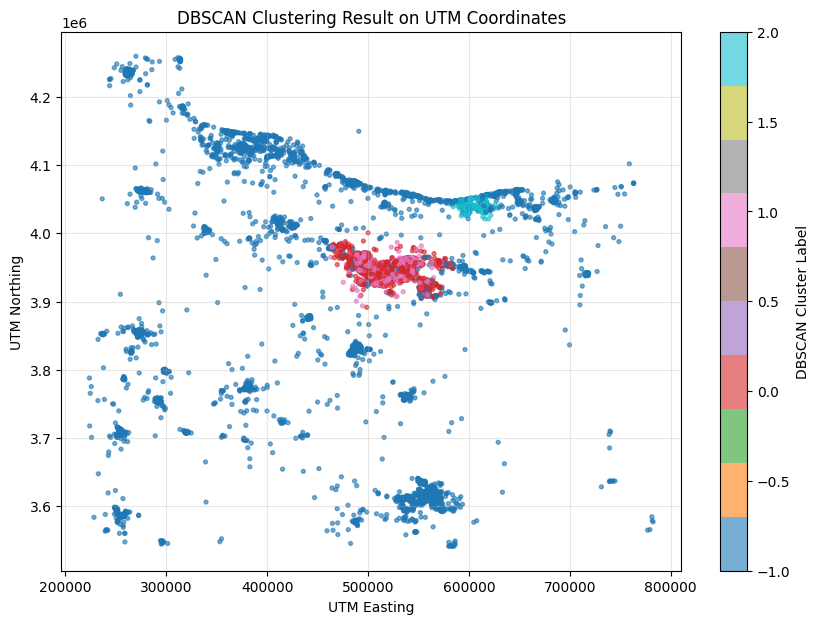

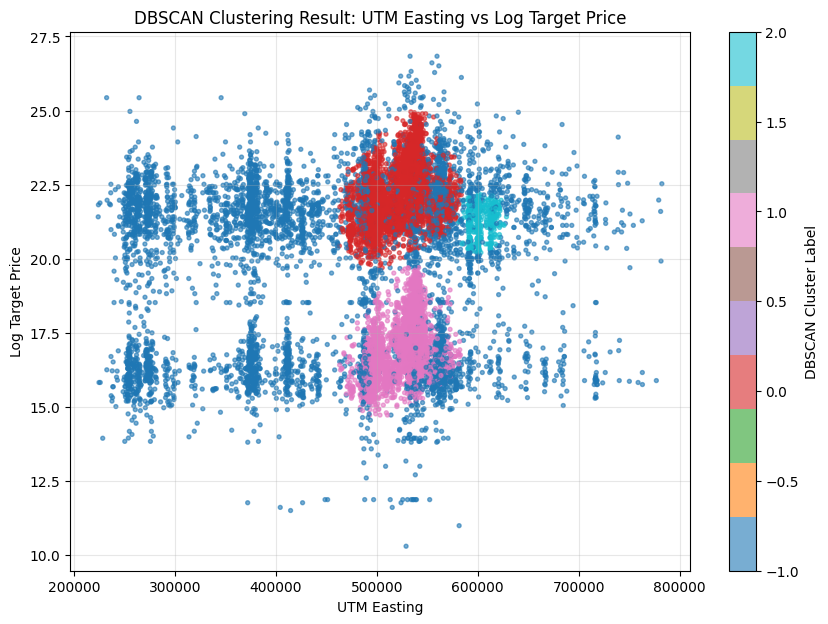

In [18]:
# Plot DBSCAN clusters on UTM coordinates
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_dbscan_final["utm_easting"],
    df_dbscan_final["utm_northing"],
    c=df_dbscan_final["dbscan_cluster"],
    s=8,
    alpha=0.6,
    cmap="tab10"
)

plt.xlabel("UTM Easting")
plt.ylabel("UTM Northing")
plt.title("DBSCAN Clustering Result on UTM Coordinates")
plt.colorbar(scatter, label="DBSCAN Cluster Label")
plt.grid(True, alpha=0.3)

plt.show()


# Plot DBSCAN clusters using UTM Easting and log target price
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_dbscan_final["utm_easting"],
    df_dbscan_final["log_target_price"],
    c=df_dbscan_final["dbscan_cluster"],
    s=8,
    alpha=0.6,
    cmap="tab10"
)

plt.xlabel("UTM Easting")
plt.ylabel("Log Target Price")
plt.title("DBSCAN Clustering Result: UTM Easting vs Log Target Price")
plt.colorbar(scatter, label="DBSCAN Cluster Label")
plt.grid(True, alpha=0.3)

plt.show()

<div dir="rtl" style="text-align: right;">

## تحلیل نهایی خروجی DBSCAN

در این بخش الگوریتم DBSCAN با استفاده از سه ویژگی `utm_easting`، `utm_northing` و `log_target_price` اجرا شد.  
در واقع مختصات UTM با دو ستون شرقی و شمالی نمایش داده شده و قیمت نیز به شکل لگاریتمی وارد مدل شده است تا اثر قیمت‌های بسیار بزرگ کمتر شود.

به دلیل سنگین بودن DBSCAN روی داده‌های بزرگ، اجرای نهایی روی یک نمونه‌ی تصادفی ۱۵ هزار ردیفی انجام شد. در تست‌های اولیه، اجرای DBSCAN روی نمونه‌ی بزرگ‌تر باعث مصرف زیاد RAM و کرش شدن محیط Colab شد. دلیل این موضوع این است که DBSCAN برای پیدا کردن نقاط پرتراکم، باید همسایگی نقاط را بررسی کند و با زیاد شدن اندازه‌ی داده یا بزرگ شدن `eps`، مصرف حافظه به شدت افزایش پیدا می‌کند.

پس از تست چند ترکیب مختلف، تنظیمات زیر برای خروجی نهایی انتخاب شد:

- `eps = 0.26`
- `min_samples = 300`

با این تنظیمات، DBSCAN سه خوشه تولید کرد و بخشی از داده‌ها را نیز به عنوان noise با label برابر `-1` جدا کرد.

خلاصه‌ی خروجی مدل:

- noise: تعداد ۵۶۷۰ آگهی، حدود ۳۷.۸۰٪ نمونه
- cluster 0: تعداد ۵۰۸۶ آگهی، حدود ۳۳.۹۱٪ نمونه
- cluster 1: تعداد ۳۸۰۷ آگهی، حدود ۲۵.۳۸٪ نمونه
- cluster 2: تعداد ۴۳۷ آگهی، حدود ۲.۹۱٪ نمونه

تحلیل خوشه‌ها نشان می‌دهد که خروجی مدل از نظر کاربرد سیستم توصیه‌گر قابل تفسیر است:

**خوشه ۰:**  
این خوشه عمدتاً شامل آگهی‌های فروش، مخصوصاً `apartment-sell` است. بیشترین شهرهای این خوشه تهران، کرج، اندیشه، پردیس و اسلام‌شهر هستند. میانه‌ی قیمت هدف در این خوشه حدود ۳.۷ میلیارد تومان است. بنابراین این خوشه را می‌توان به عنوان خوشه‌ی «املاک فروشی شهری، مخصوصاً آپارتمان‌های فروش در تهران و اطراف آن» تفسیر کرد.

**خوشه ۱:**  
این خوشه بیشتر شامل آگهی‌های اجاره، مخصوصاً `apartment-rent` است. شهرهای پرتکرار آن تهران، کرج، اندیشه، فردیس و پرند هستند. میانه‌ی قیمت هدف در این خوشه حدود ۲۲.۵ میلیون تومان است که با ماهیت آگهی‌های اجاره‌ای سازگار است. بنابراین این خوشه را می‌توان به عنوان خوشه‌ی «املاک اجاره‌ای شهری» تفسیر کرد.

**خوشه ۲:**  
این خوشه کوچک‌تر است، اما از نظر معنایی قابل توجه است. بیشتر آگهی‌های آن از نوع `house-villa-sell` و سپس `plot-old` هستند. شهرهای پرتکرار آن چمستان، نور، محمودآباد، آمل و ایزدشهر هستند. میانه‌ی قیمت هدف این خوشه حدود ۱.۷۵ میلیارد تومان و میانه‌ی متراژ آن حدود ۱۴۰ متر است. بنابراین این خوشه را می‌توان به عنوان خوشه‌ی «ویلا و زمین در شهرهای شمالی» تفسیر کرد.

در نمودار مکانی UTM نیز دیده می‌شود که خوشه ۲ از نظر جغرافیایی از دو خوشه‌ی اصلی دیگر جداست و در ناحیه‌ای متفاوت قرار دارد. همچنین در نمودار `utm_easting` در برابر `log_target_price`، خوشه‌های فروش و اجاره از نظر سطح قیمت از یکدیگر جدا می‌شوند.

اثر هایپرپارامترها در DBSCAN به این صورت بود:

- با افزایش `eps`، نقاط بیشتری همسایه‌ی هم در نظر گرفته می‌شوند. در نتیجه معمولاً تعداد noise کمتر می‌شود و بعضی خوشه‌ها با هم ادغام می‌شوند.
- با افزایش `min_samples`، مدل سخت‌گیرتر می‌شود. یعنی برای تشکیل یک خوشه، تراکم بیشتری لازم است. در نتیجه خوشه‌های کوچک‌تر ممکن است به noise تبدیل شوند و تعداد خوشه‌های نهایی کمتر شود.
- در این پروژه، اگر `eps` خیلی کوچک باشد، مدل تعداد زیادی خوشه‌ی کوچک و noise زیاد تولید می‌کند.
- اگر `eps` خیلی بزرگ شود، خوشه‌های مختلف بیش از حد با هم ادغام می‌شوند و تفکیک معنایی کاهش پیدا می‌کند.

در مقایسه با KMeans، الگوریتم DBSCAN چند تفاوت مهم دارد. در KMeans باید تعداد خوشه‌ها از ابتدا مشخص شود، اما DBSCAN تعداد خوشه‌ها را بر اساس تراکم داده‌ها پیدا می‌کند. همچنین KMeans همه‌ی نقاط را به یک خوشه اختصاص می‌دهد، ولی DBSCAN می‌تواند نقاط پرت را به عنوان noise جدا کند. از طرف دیگر، DBSCAN روی داده‌های بزرگ از نظر حافظه و زمان سنگین‌تر است و انتخاب `eps` و `min_samples` حساسیت زیادی دارد.

در مجموع، خروجی DBSCAN با سه خوشه‌ی به‌دست‌آمده برای این مسئله قابل دفاع است، چون خوشه‌ها از نظر نوع معامله، سطح قیمت و موقعیت جغرافیایی معنی‌دار هستند. با این حال، به دلیل محدودیت حافظه، این تحلیل روی نمونه‌ی ۱۵ هزار ردیفی انجام شده و برای استفاده‌ی عملی در سیستم توصیه‌گر واقعی، بهتر است در آینده روی زیرمجموعه‌های شهری یا با روش‌های بهینه‌تر مقیاس‌پذیر اجرا شود.

</div>